<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="https://campusvirtual.urv.cat/pluginfile.php/1/core_admin/logocompact/300x300/1767733831/logoURVppd.png", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">2025-2026 SCIENTIFIC PROGRAMMING (17715101)</p>
<p style="margin: 0; text-align:right;">MD Health Data Science / Biomedical Data Science</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

# Step 5: Model Validation and Selection

**Objective**: Implement validation strategy and select best model for API implementation

**Inputs**: Training and test sets

**Outputs**: Validation metrics, selected model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sys.path.append('../src')

from model.validation import (
    train_test_validation,
    cross_validation,
    select_best_model,
    save_validation_results,
    save_best_model
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Load Data

In [2]:
df = pd.read_csv('../data/breast_cancer_reduced.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (569, 22)

Columns: ['mean_radius', 'mean_texture', 'mean_smoothness', 'mean_compactness', 'mean_concavity', 'mean_symmetry', 'mean_fractal_dimension', 'radius_error', 'texture_error', 'smoothness_error', 'compactness_error', 'concavity_error', 'concave_points_error', 'symmetry_error', 'fractal_dimension_error', 'worst_smoothness', 'worst_compactness', 'worst_concavity', 'worst_symmetry', 'worst_fractal_dimension', 'diagnosis', 'diagnosis_label']


,mean_radius,mean_texture,mean_smoothness,mean_compactness,mean_concavity,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,smoothness_error,...,concave_points_error,symmetry_error,fractal_dimension_error,worst_smoothness,worst_compactness,worst_concavity,worst_symmetry,worst_fractal_dimension,diagnosis,diagnosis_label
0,17.99,10.38,0.11840,0.27760,0.3001,0.2419,0.07871,1.0950,0.9053,0.006399,...,0.01587,0.03003,0.006193,0.1622,0.6656,0.7119,0.4601,0.11890,0,malignant
1,20.57,17.77,0.08474,0.07864,0.0869,0.1812,0.05667,0.5435,0.7339,0.005225,...,0.01340,0.01389,0.003532,0.1238,0.1866,0.2416,0.2750,0.08902,0,malignant
2,19.69,21.25,0.10960,0.15990,0.1974,0.2069,0.05999,0.7456,0.7869,0.006150,...,0.02058,0.02250,0.004571,0.1444,0.4245,0.4504,0.3613,0.08758,0,malignant
3,11.42,20.38,0.14250,0.28390,0.2414,0.2597,0.09744,0.4956,1.1560,0.009110,...,0.01867,0.05963,0.009208,0.2098,0.8663,0.6869,0.6638,0.17300,0,malignant
4,20.29,14.34,0.10030,0.13280,0.1980,0.1809,0.05883,0.7572,0.7813,0.011490,...,0.01885,0.01756,0.005115,0.1374,0.2050,0.4000,0.2364,0.07678,0,malignant


In [3]:
y = df['diagnosis'].astype(int)
X = df.drop(['diagnosis', 'diagnosis_label'], axis=1)

print(f"Features: {X.shape[1]} columns")
print(f"Samples: {X.shape[0]}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nClass balance: {y.value_counts(normalize=True)}")

Features: 20 columns
Samples: 569

Target distribution:
diagnosis
1    357
0    212
Name: count, dtype: int64

Class balance: diagnosis
1    0.627417
0    0.372583
Name: proportion, dtype: float64


## 2. Train/Test Split Validation

We'll split the data into 80% training and 20% test sets, then evaluate KNN models with different k values.

In [4]:
n_neighbors_list = [3, 5, 7, 9, 11, 13, 15]

train_test_results, (X_train, X_test, y_train, y_test) = train_test_validation(
    X, y,
    test_size=0.2,
    random_state=42,
    n_neighbors_list=n_neighbors_list
)

Training set size: 455 samples
Test set size: 114 samples
Class distribution in training: {1: 285, 0: 170}
Class distribution in test: {1: 72, 0: 42}

Training KNN with k=3...
  Train Accuracy: 0.9451
  Test Accuracy: 0.8947
  Test F1-Score: 0.9155

Training KNN with k=5...
  Train Accuracy: 0.9209
  Test Accuracy: 0.9035
  Test F1-Score: 0.9220

Training KNN with k=7...
  Train Accuracy: 0.9165
  Test Accuracy: 0.8684
  Test F1-Score: 0.8966

Training KNN with k=9...
  Train Accuracy: 0.9121
  Test Accuracy: 0.8947
  Test F1-Score: 0.9155

Training KNN with k=11...
  Train Accuracy: 0.9121
  Test Accuracy: 0.9123
  Test F1-Score: 0.9296

Training KNN with k=13...
  Train Accuracy: 0.9077
  Test Accuracy: 0.9035
  Test F1-Score: 0.9231

Training KNN with k=15...
  Train Accuracy: 0.9077
  Test Accuracy: 0.8947
  Test F1-Score: 0.9155



### Visualize Train/Test Results

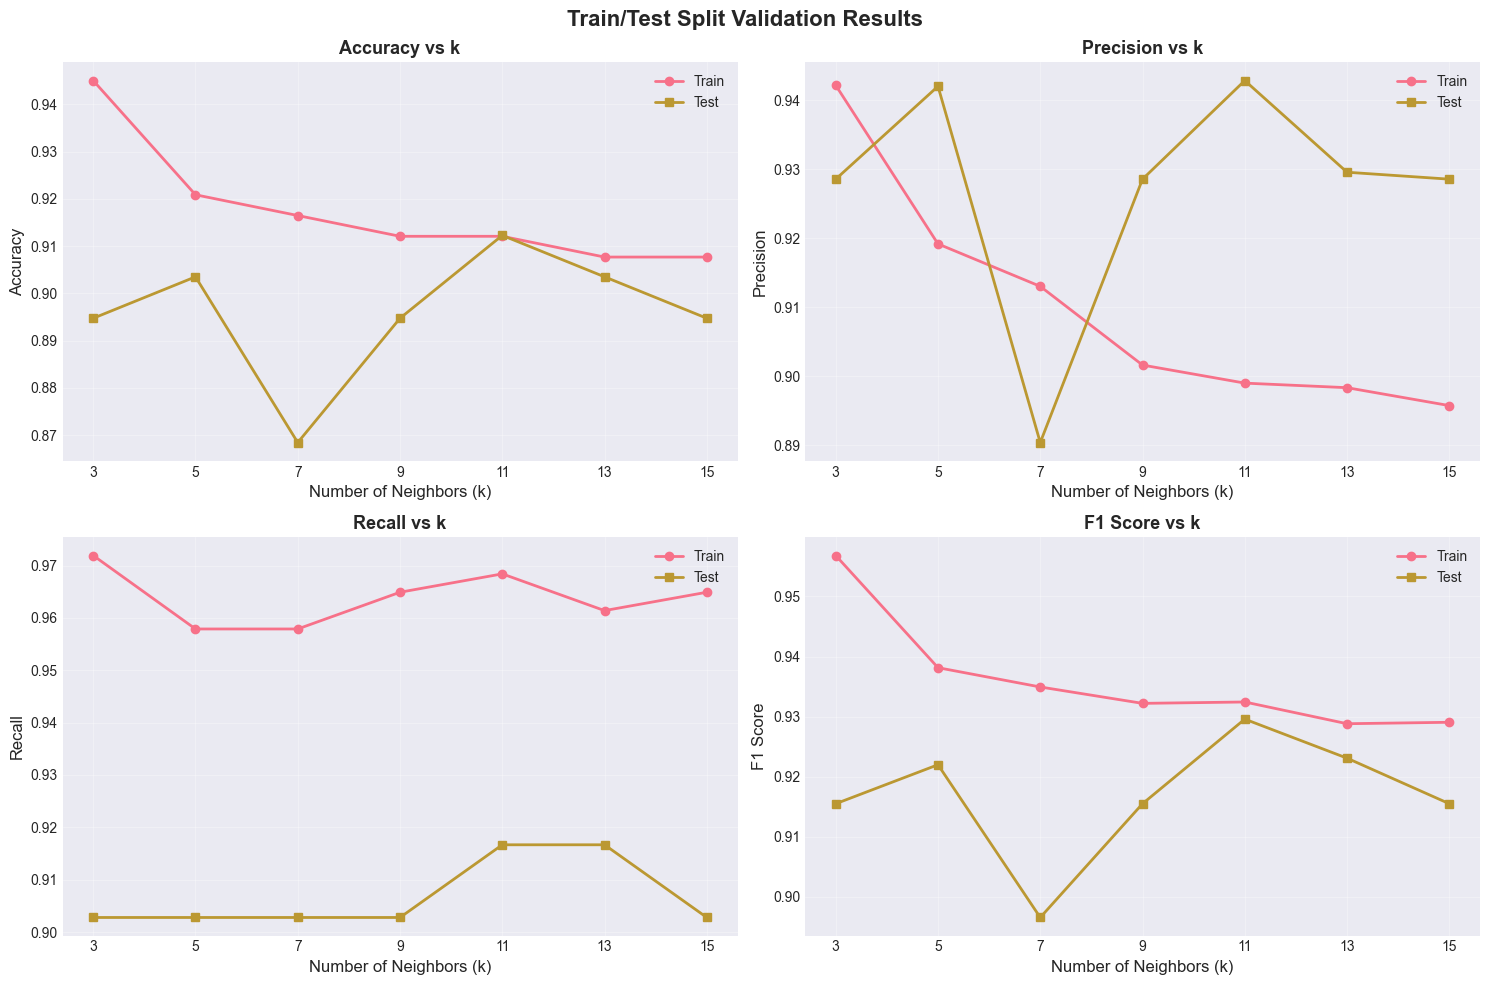

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Train/Test Split Validation Results', fontsize=16, fontweight='bold')

metrics = ['accuracy', 'precision', 'recall', 'f1_score']
k_values = []
train_scores = {m: [] for m in metrics}
test_scores = {m: [] for m in metrics}

for model_name, model_data in train_test_results['models'].items():
    k_values.append(model_data['n_neighbors'])
    for metric in metrics:
        train_scores[metric].append(model_data['train_metrics'][metric])
        test_scores[metric].append(model_data['test_metrics'][metric])

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    ax.plot(k_values, train_scores[metric], marker='o', label='Train', linewidth=2)
    ax.plot(k_values, test_scores[metric], marker='s', label='Test', linewidth=2)
    ax.set_xlabel('Number of Neighbors (k)', fontsize=12)
    ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=12)
    ax.set_title(f'{metric.replace("_", " ").title()} vs k', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(k_values)

plt.tight_layout()
plt.show()

## 3. Cross-Validation

Perform 5-fold cross-validation to get a more robust estimate of model performance.

In [6]:
cv_results = cross_validation(
    X, y,
    cv_folds=5,
    random_state=42,
    n_neighbors_list=n_neighbors_list
)

Performing 5-fold cross-validation...
Total samples: 569

Cross-validating KNN with k=3...
  Accuracy: 0.8893 (+/- 0.0420)
  F1-Score: 0.9157 (+/- 0.0282)

Cross-validating KNN with k=5...
  Accuracy: 0.8963 (+/- 0.0320)
  F1-Score: 0.9204 (+/- 0.0216)

Cross-validating KNN with k=7...
  Accuracy: 0.8858 (+/- 0.0337)
  F1-Score: 0.9121 (+/- 0.0234)

Cross-validating KNN with k=9...
  Accuracy: 0.8963 (+/- 0.0365)
  F1-Score: 0.9203 (+/- 0.0258)

Cross-validating KNN with k=11...
  Accuracy: 0.8946 (+/- 0.0350)
  F1-Score: 0.9194 (+/- 0.0245)

Cross-validating KNN with k=13...
  Accuracy: 0.8875 (+/- 0.0325)
  F1-Score: 0.9138 (+/- 0.0227)

Cross-validating KNN with k=15...
  Accuracy: 0.8893 (+/- 0.0280)
  F1-Score: 0.9148 (+/- 0.0197)



### Visualize Cross-Validation Results

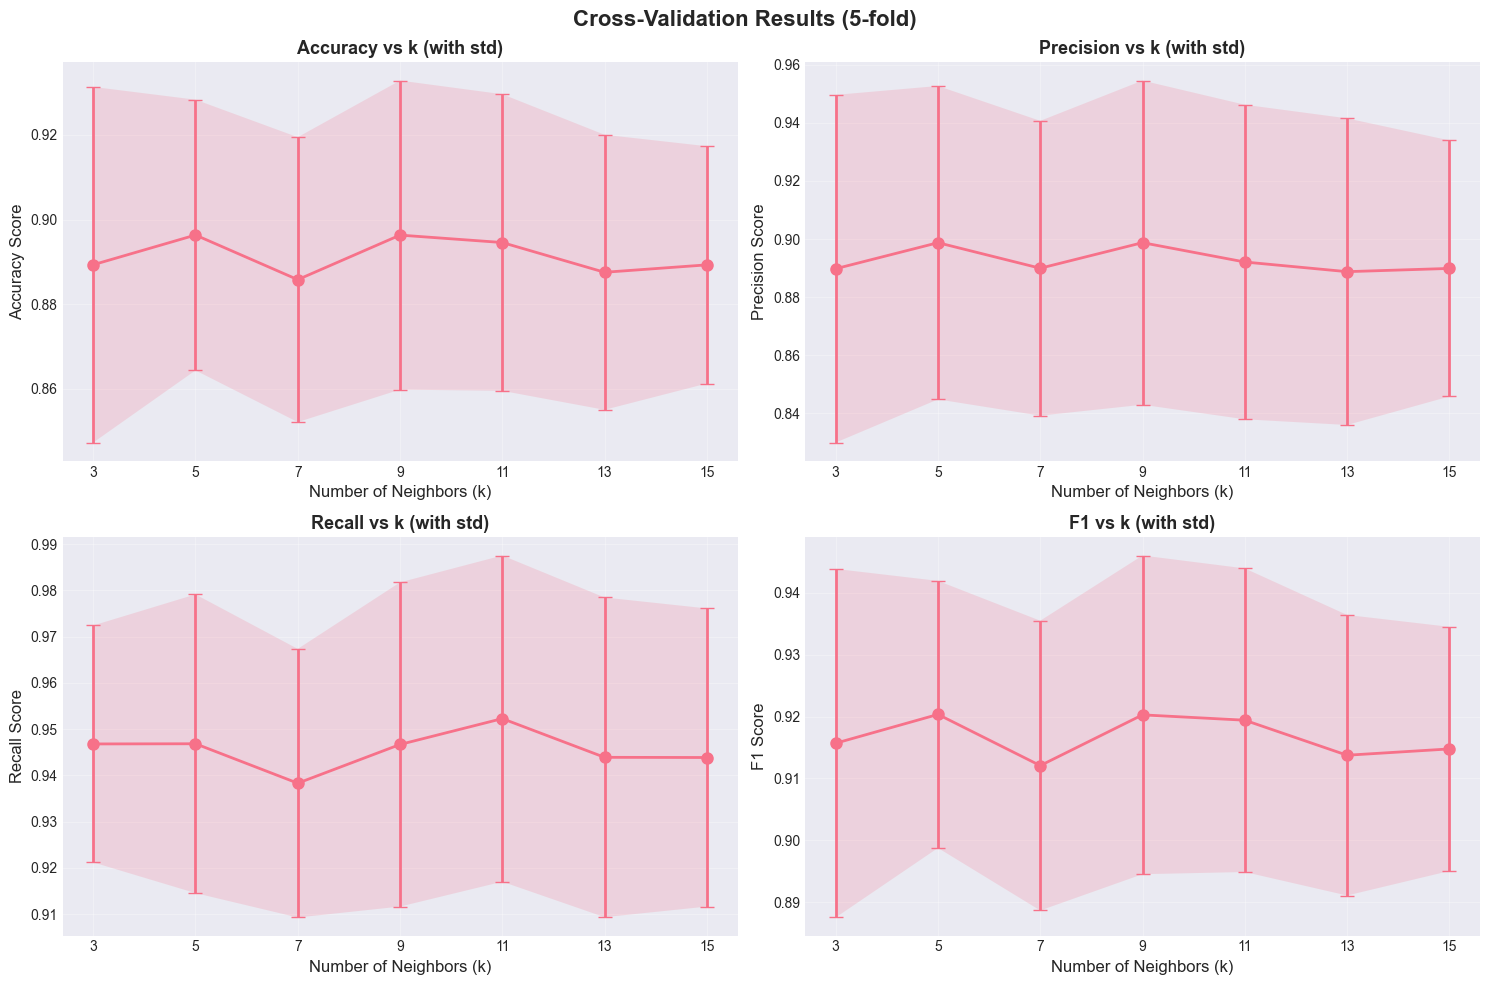

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Cross-Validation Results (5-fold)', fontsize=16, fontweight='bold')

metrics_cv = ['accuracy', 'precision', 'recall', 'f1']
k_values_cv = []
cv_means = {m: [] for m in metrics_cv}
cv_stds = {m: [] for m in metrics_cv}

for model_name, model_data in cv_results['models'].items():
    k_values_cv.append(model_data['n_neighbors'])
    for metric in metrics_cv:
        cv_means[metric].append(model_data['cv_metrics'][f'{metric}_mean'])
        cv_stds[metric].append(model_data['cv_metrics'][f'{metric}_std'])

for idx, metric in enumerate(metrics_cv):
    ax = axes[idx // 2, idx % 2]
    means = cv_means[metric]
    stds = cv_stds[metric]
    
    ax.errorbar(k_values_cv, means, yerr=stds, marker='o', capsize=5, 
                linewidth=2, markersize=8, label=f'{metric.title()}')
    ax.fill_between(k_values_cv, 
                     [m - s for m, s in zip(means, stds)],
                     [m + s for m, s in zip(means, stds)],
                     alpha=0.2)
    ax.set_xlabel('Number of Neighbors (k)', fontsize=12)
    ax.set_ylabel(f'{metric.title()} Score', fontsize=12)
    ax.set_title(f'{metric.title()} vs k (with std)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(k_values_cv)

plt.tight_layout()
plt.show()

## 4. Model Comparison

Compare all models side by side.

In [8]:
comparison_data = []

for model_name in train_test_results['models'].keys():
    k = train_test_results['models'][model_name]['n_neighbors']
    
    test_acc = train_test_results['models'][model_name]['test_metrics']['accuracy']
    test_f1 = train_test_results['models'][model_name]['test_metrics']['f1_score']
    
    cv_acc = cv_results['models'][model_name]['cv_metrics']['accuracy_mean']
    cv_acc_std = cv_results['models'][model_name]['cv_metrics']['accuracy_std']
    cv_f1 = cv_results['models'][model_name]['cv_metrics']['f1_mean']
    cv_f1_std = cv_results['models'][model_name]['cv_metrics']['f1_std']
    
    comparison_data.append({
        'k': k,
        'Test Accuracy': f"{test_acc:.4f}",
        'Test F1': f"{test_f1:.4f}",
        'CV Accuracy': f"{cv_acc:.4f} ± {cv_acc_std:.4f}",
        'CV F1': f"{cv_f1:.4f} ± {cv_f1_std:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Comparison Summary:")
print("="*80)
comparison_df


Model Comparison Summary:


,k,Test Accuracy,Test F1,CV Accuracy,CV F1
0,3,0.8947,0.9155,0.8893 ± 0.0420,0.9157 ± 0.0282
1,5,0.9035,0.9220,0.8963 ± 0.0320,0.9204 ± 0.0216
2,7,0.8684,0.8966,0.8858 ± 0.0337,0.9121 ± 0.0234
3,9,0.8947,0.9155,0.8963 ± 0.0365,0.9203 ± 0.0258
4,11,0.9123,0.9296,0.8946 ± 0.0350,0.9194 ± 0.0245
5,13,0.9035,0.9231,0.8875 ± 0.0325,0.9138 ± 0.0227
6,15,0.8947,0.9155,0.8893 ± 0.0280,0.9148 ± 0.0197


## 5. Model Selection

Select the best model based on validation results.

In [9]:
best_model_name, selection_summary = select_best_model(
    train_test_results,
    cv_results,
    metric='f1_score'
)


MODEL SELECTION BASED ON VALIDATION RESULTS

Train/Test Split Results:
------------------------------------------------------------
knn_k3: Test f1_score=0.9155, Train f1_score=0.9568, Overfit=0.0413
knn_k5: Test f1_score=0.9220, Train f1_score=0.9381, Overfit=0.0162
knn_k7: Test f1_score=0.8966, Train f1_score=0.9349, Overfit=0.0384
knn_k9: Test f1_score=0.9155, Train f1_score=0.9322, Overfit=0.0167
knn_k11: Test f1_score=0.9296, Train f1_score=0.9324, Overfit=0.0029
knn_k13: Test f1_score=0.9231, Train f1_score=0.9288, Overfit=0.0057
knn_k15: Test f1_score=0.9155, Train f1_score=0.9291, Overfit=0.0136

Cross-Validation Results:
------------------------------------------------------------
knn_k3: CV f1_score=0.9157 (+/- 0.0282)
knn_k5: CV f1_score=0.9204 (+/- 0.0216)
knn_k7: CV f1_score=0.9121 (+/- 0.0234)
knn_k9: CV f1_score=0.9203 (+/- 0.0258)
knn_k11: CV f1_score=0.9194 (+/- 0.0245)
knn_k13: CV f1_score=0.9138 (+/- 0.0227)
knn_k15: CV f1_score=0.9148 (+/- 0.0197)

Selection Criter

## 6. Best Model Details

In [10]:
best_model = train_test_results['models'][best_model_name]['model']
best_k = train_test_results['models'][best_model_name]['n_neighbors']

print(f"\n{'='*80}")
print("SELECTED MODEL FOR API IMPLEMENTATION")
print(f"{'='*80}\n")
print(f"Model: KNeighborsClassifier")
print(f"Hyperparameter: n_neighbors = {best_k}")

print(f"\nTest Set Performance:")
test_metrics = train_test_results['models'][best_model_name]['test_metrics']
for metric_name, value in test_metrics.items():
    if metric_name != 'confusion_matrix':
        print(f"  {metric_name}: {value:.4f}")

print(f"\nCross-Validation Performance:")
cv_metrics = cv_results['models'][best_model_name]['cv_metrics']
print(f"  Accuracy: {cv_metrics['accuracy_mean']:.4f} (+/- {cv_metrics['accuracy_std']:.4f})")
print(f"  Precision: {cv_metrics['precision_mean']:.4f} (+/- {cv_metrics['precision_std']:.4f})")
print(f"  Recall: {cv_metrics['recall_mean']:.4f} (+/- {cv_metrics['recall_std']:.4f})")
print(f"  F1-Score: {cv_metrics['f1_mean']:.4f} (+/- {cv_metrics['f1_std']:.4f})")


SELECTED MODEL FOR API IMPLEMENTATION

Model: KNeighborsClassifier
Hyperparameter: n_neighbors = 5

Test Set Performance:
  accuracy: 0.9035
  precision: 0.9420
  recall: 0.9028
  f1_score: 0.9220
  specificity: 0.9048

Cross-Validation Performance:
  Accuracy: 0.8963 (+/- 0.0320)
  Precision: 0.8988 (+/- 0.0539)
  Recall: 0.9468 (+/- 0.0323)
  F1-Score: 0.9204 (+/- 0.0216)


### Confusion Matrix for Best Model

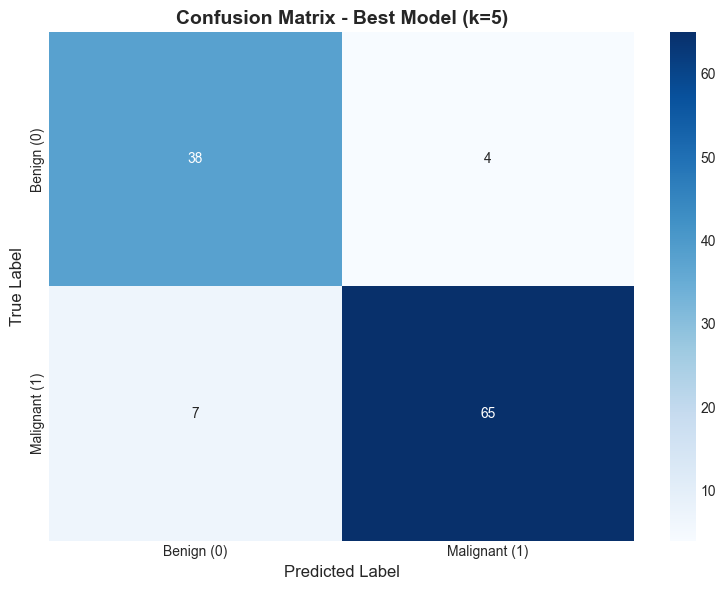


Confusion Matrix Breakdown:
  True Negatives (TN): 38
  False Positives (FP): 4
  False Negatives (FN): 7
  True Positives (TP): 65


In [11]:
cm = np.array(test_metrics['confusion_matrix'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.title(f'Confusion Matrix - Best Model (k={best_k})', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives (TN): {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives (TP): {tp}")

## 7. Save Results

In [12]:
results_path = Path('../results')
results_path.mkdir(exist_ok=True)

save_validation_results(
    train_test_results,
    str(results_path / 'train_test_validation_results.json')
)

save_validation_results(
    cv_results,
    str(results_path / 'cross_validation_results.json')
)

save_validation_results(
    selection_summary,
    str(results_path / 'model_selection_summary.json')
)

save_best_model(
    best_model,
    str(results_path / 'best_model.pkl')
)

print("\n✓ All results saved successfully!")


Validation results saved to: ../results/train_test_validation_results.json

Validation results saved to: ../results/cross_validation_results.json

Validation results saved to: ../results/model_selection_summary.json
Best model saved to: ../results/best_model.pkl

✓ All results saved successfully!


## Conclusion

**Step 5 Complete**: We have successfully:
1. ✓ Implemented train/test split validation (80/20)
2. ✓ Implemented 5-fold cross-validation
3. ✓ Evaluated multiple KNN models with different k values
4. ✓ Selected the best model based on F1-score
5. ✓ Saved validation metrics and the selected model

The selected model is ready for API implementation in the next step.